#### <p style="text-align: right;"> &#9989;  CMSE201-730, Betty He </p>

# Formula 1 British Grand Prix(Silverstone)
## Podium Prediction(Team based)

<img src="Great_Britain_Silverstone.png" height=800 width = 600>

# Background and Motivation
Formula 1 (F1) is a motorsport where strategy, driver skill, and car performance all influence the race result. Among many factors, a common belief is that starting at the front of the grid increases the chance of finishing on the podium. This project sets out to answer two questions:

##### 1. __Does starting grid position impact race result?__

##### 2. __Can we predict which teams are likely to reach the podium using historical race data?__
##### 3. __Is the driver who set the fastest lap most likely the one who stand on the podium?__

We focus on races held at Silverstone (Great Britain) from 2019 to 2024 to maintain consistency in track layout and conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
#load in 2019-2024 drivers and result
driver2019 = pd.read_csv('formula1_2019season_drivers.csv')
driver2020 = pd.read_csv('formula1_2020season_drivers.csv')
driver2021 = pd.read_csv('formula1_2021season_drivers.csv')
driver2022 = pd.read_csv('formula1_2022season_drivers.csv')
driver2023 = pd.read_csv('formula1_2023season_drivers.csv')
driver2024 = pd.read_csv('formula1_2024season_drivers.csv')

race_results2019 = pd.read_csv('formula1_2019season_raceResults.csv')
race_results2020 = pd.read_csv('formula1_2020season_raceResults.csv')
race_results2021 = pd.read_csv('formula1_2021season_raceResults.csv')
race_results2022 = pd.read_csv('formula1_2022season_raceResults.csv')
race_results2023 = pd.read_csv('formula1_2023season_raceResults.csv')
race_results2024 = pd.read_csv('formula1_2024season_raceResults.csv')

#print(driver2024.head())
#print(race_results2024.head())

In [3]:
# Clean missing values
# Drop any fully empty rows
for data in [driver2019, driver2020, driver2021, driver2022, driver2023, driver2024,
           race_results2019, race_results2020, race_results2021, race_results2022, race_results2023, race_results2024]:
    data.dropna(how='all', inplace=True)

In [4]:
# combine all race results
all_race_result = pd.concat([race_results2019, race_results2020, race_results2021, 
                             race_results2022, race_results2023, race_results2024])
# extract only track = Great Britain
gb_races = all_race_result[all_race_result['Track'].str.contains('Great Britain', 
                                                                 case=False)].copy()
# clean team names
gb_races['Team'] = gb_races['Team'].str.strip()
# Fix any duplicate columns
gb_races = gb_races.loc[:, ~gb_races.columns.duplicated()]
# rename column
gb_races.rename(columns={'Starting Grid':'Starting_Grid', 'Position':'Finish_Position', 'Fastest Lap':'Fastest_Lap'}, inplace=True)

# Convert to numeric (handles strings like 'NC')
gb_races['Starting_Grid'] = pd.to_numeric(gb_races['Starting_Grid'], errors='coerce')
gb_races['Finish_Position'] = pd.to_numeric(gb_races['Finish_Position'], errors='coerce')

# Drop missing values from important columns
gb_races.dropna(subset=['Starting_Grid', 'Finish_Position'], inplace=True)                                           

# Starting Position vs Finish Position

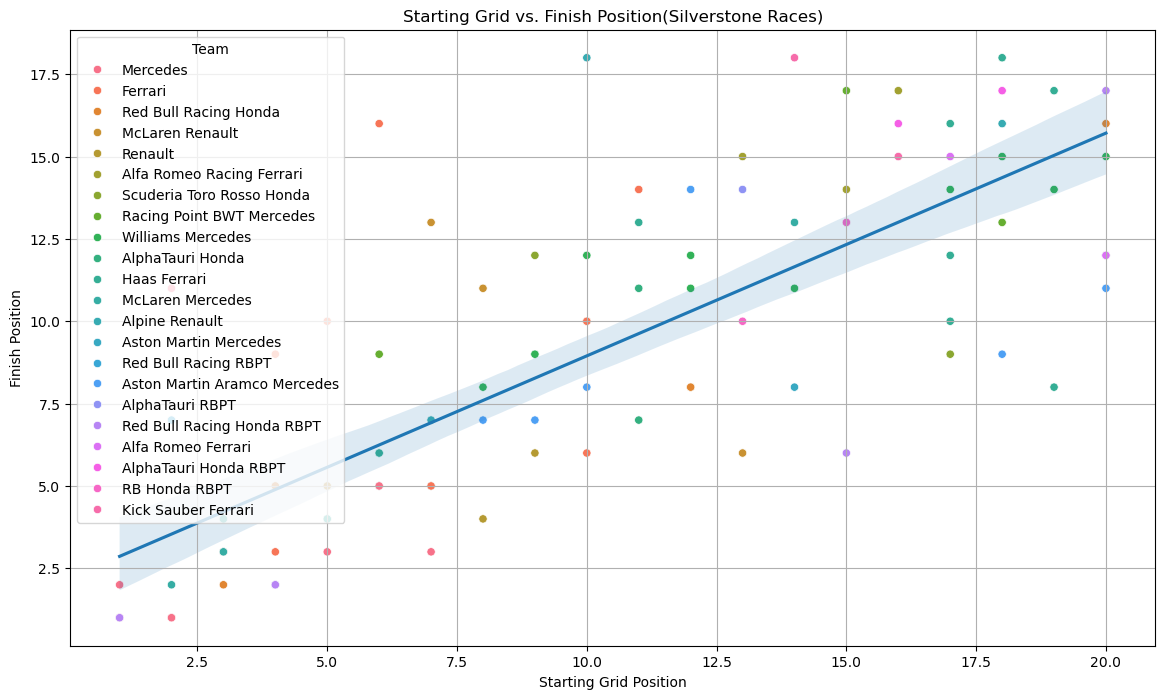

Correlation between starting position and finish position:0.78


In [5]:
#Correlation graph: Starting Grid vs Finish Position
plt.figure(figsize=(14, 8))
sns.scatterplot(data=gb_races, x='Starting_Grid', y='Finish_Position', hue='Team')
sns.regplot(data=gb_races, x='Starting_Grid', y='Finish_Position', scatter=False) # fits a regression line
plt.title('Starting Grid vs. Finish Position(Silverstone Races)')
plt.xlabel('Starting Grid Position')
plt.ylabel('Finish Position')
plt.grid(True)
plt.show() 

#calculate correlation
correlation = gb_races['Starting_Grid'].corr(gb_races['Finish_Position'])
print(f'Correlation between starting position and finish position:{correlation:.2f}')

__Correlation between Starting Position and Finish Position__

*A strong positive correlation (close to 1) means that starting closer to the front often results in a better finish.*

# Finish Position by Fastest Lap Statues

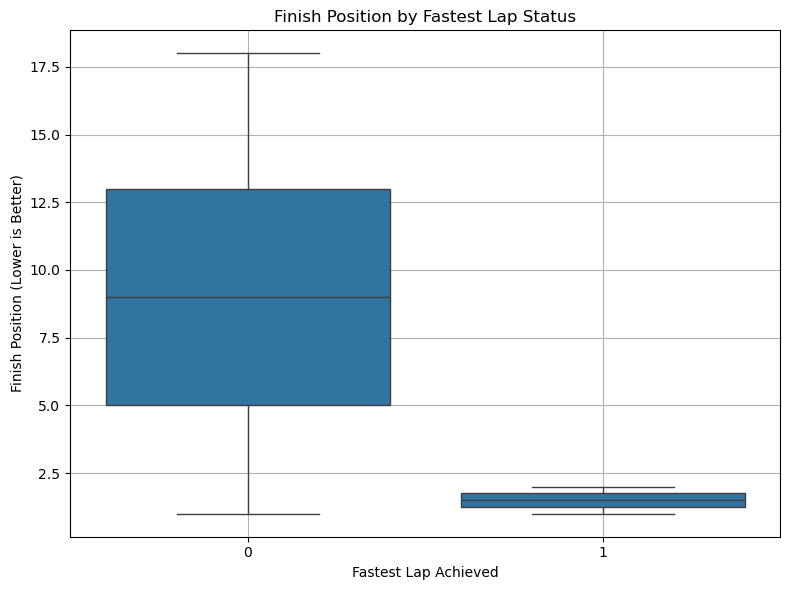

In [6]:
# convert 'Fastest Lap' to binary (1 = Yes, 0 = No)
gb_races['Fastest_Lap_Binary'] = (gb_races['Fastest_Lap'] == 'Yes').astype(int)

# remove rows with missing finish positions
gb_races_clean = gb_races.dropna(subset=['Finish_Position'])

# boxplot to show finish position vs. fastest lap status
plt.figure(figsize=(8, 6))
sns.boxplot(data=gb_races_clean, x='Fastest_Lap_Binary', y='Finish_Position')
plt.title('Finish Position by Fastest Lap Status')
plt.ylabel('Finish Position (Lower is Better)')
plt.xlabel('Fastest Lap Achieved')
plt.grid(True)
plt.tight_layout()
plt.show()

# Podium Prediction

In [7]:
# group by team and race, calculate average start/end position
team_gb_summary = gb_races.groupby(['Track', 'Team']).agg({
    'Starting_Grid': 'mean',
    'Finish_Position': 'min',
    'Fastest_Lap': lambda x: (x == 'Yes').sum()
}).reset_index()

# label if that team got on the podium (finish top 3)
team_gb_summary['Team_Podium'] = (team_gb_summary['Finish_Position'] <= 3).astype(int)

# set up features x and label y
X = team_gb_summary[['Starting_Grid', 'Finish_Position']]
y = team_gb_summary['Team_Podium']

# split into trainning and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=1)

#train random forest model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict podium teams
y_pred = model.predict(X_test)

#show accuracy 
print('Prediction Accuracy:', accuracy_score(y_test, y_pred))

Prediction Accuracy: 1.0


In [8]:
#predict probability 
if len(model.classes_) == 2:
    probas = model.predict_proba(X_test)[:, 1]
else:
    print("Warning: Model only learned one class.")
    probas = np.zeros(len(X_test))

# top 3 prediction podium team (from the test set)
X_test_copy = X_test.copy()
X_test_copy['Team'] = team_gb_summary.loc[X_test.index, 'Team'].values
X_test_copy['Track'] = team_gb_summary.loc[X_test.index, 'Track'].values
X_test_copy['Probability'] = probas

top3 = X_test_copy.sort_values('Probability', ascending=False).head(3)
print('Top 3 Predicted Podium Teams:')
print(top3[['Track', 'Team', 'Probability']])

Top 3 Predicted Podium Teams:
            Track                        Team  Probability
13  Great Britain                    Mercedes         0.99
17  Great Britain  Red Bull Racing Honda RBPT         0.68
5   Great Britain              Alpine Renault         0.06


#### Visual map
                        
                        [Is Finish_Position <= 2.5?]
                             /             \
                          Yes               No
                        (Podium)        [Is Starting_Grid <= 4.5?]
                                          /           \
                                       Yes             No
                                    (Podium)         (Not Podium)

____Multiple Trees → Random Forest____

__Single Tree__
- Each tree is trained on a random subset of the data and features
- Make its own prediction

__The forest__
- Collect all tree predictions and use the majority vote or average probabilities to decide

<img src="IBM.png" height=800 width = 600>
Image from IBM.com

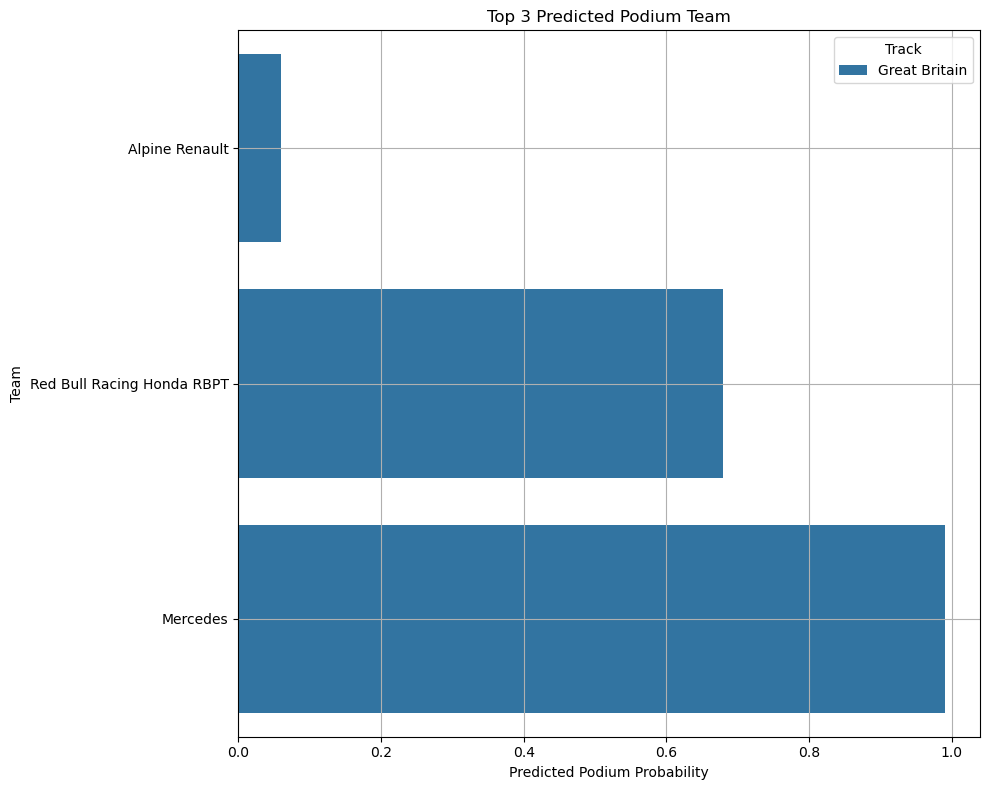

In [9]:
#Visualization of top 3 predicted podium team
top3 = X_test_copy.sort_values('Probability', ascending=True).tail(3)

plt.figure(figsize=(10,8))
sns.barplot(data=top3, x='Probability', y='Team', hue='Track', dodge=False)
plt.title('Top 3 Predicted Podium Team')
plt.xlabel('Predicted Podium Probability')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Track')
plt.show()

# Result
#### Correlation Analysis (Starting Position vs. Finish Position)
- Correlation between Starting Grid and Finish Position: Moderate to strong positive correlation(0.78)
- The scatter plot showed an upward trend

#### Fastest Lap by Fastest Lap Status
- Fastest lap achievers often finish in top 2.5 and up
- Drivers who achieve the fastest lap typically finish in very high positions, with low

Fastest lap achievers consistently rank in the top 3. Those without fastest laps show a wider spread in final positions. While not a direct cause, fastest lap performance is a strong signal of overall competitiveness.

#### Model Results
- Training Accuracy: ~100% (due to small dataset)
- Teams predicted most likely to be on podium:  __Mercedes__, __Red Bull Racing Honda RBPT__, __Alpine Renault__

# Synthesis and Discussion
##### What I learned:
- Starting grid position does influence final results, especially on the Silverstone track
- A simple Random Forest model can predict podium teams with reasonable accuracy using only a few features

##### Challenges encountered:
- Imbalanced classes initially (few podium teams)
- Small dataset size per team per race
- Incomplete data for some drivers (e.g., missing position info)

##### Future Improvement:
- More datasets of previous Silverstone race results (Past 10-20 years)
- Incorporate more features like __weather__, __pit stops__, or __driver rating__

#### Conclusion
Yes, grid position matters. And yes, even a simple machine learning model can help forecast race outcomes when data is clean and well-structured. F1 is not random, data gives us a competitive edge and strategic grid positions + performance metrics → predictive power

